In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sales = sns.load_dataset("tips")

sales.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [5]:
sales.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [6]:
sales_by_day = sales.groupby("day")["total_bill"].sum()

sales_by_day

day
Thur    1096.33
Fri      325.88
Sat     1778.40
Sun     1627.16
Name: total_bill, dtype: float64

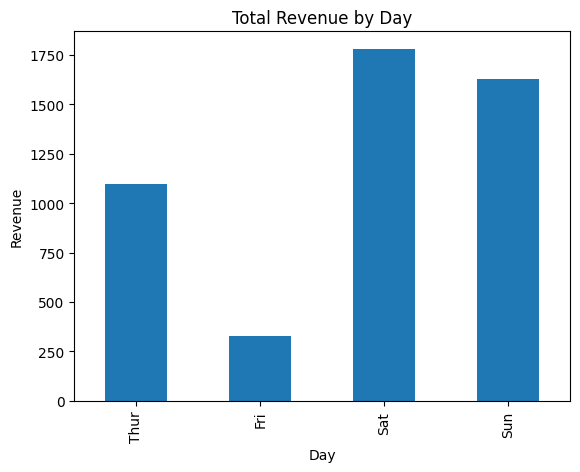

In [7]:
sales_by_day.plot(kind="bar")

plt.title("Total Revenue by Day")
plt.xlabel("Day")
plt.ylabel("Revenue")

plt.show()

In [8]:
avg_bill = sales.groupby("time")["total_bill"].mean()

avg_bill

time
Lunch     17.168676
Dinner    20.797159
Name: total_bill, dtype: float64

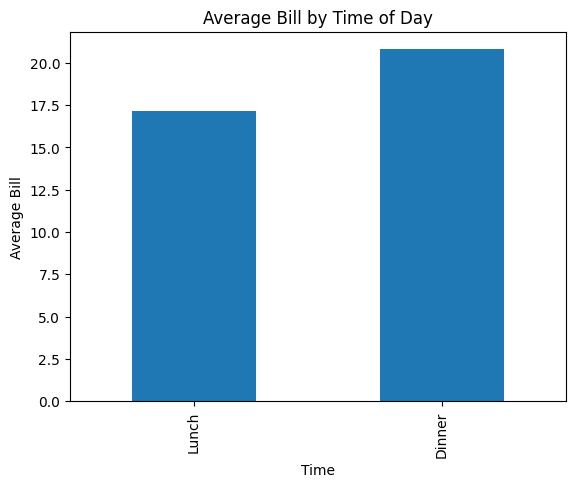

In [9]:
avg_bill.plot(kind="bar")

plt.title("Average Bill by Time of Day")
plt.xlabel("Time")
plt.ylabel("Average Bill")

plt.show()

In [10]:
group_size = sales.groupby("size")["total_bill"].mean()

group_size

size
1     7.242500
2    16.448013
3    23.277632
4    28.613514
5    30.068000
6    34.830000
Name: total_bill, dtype: float64

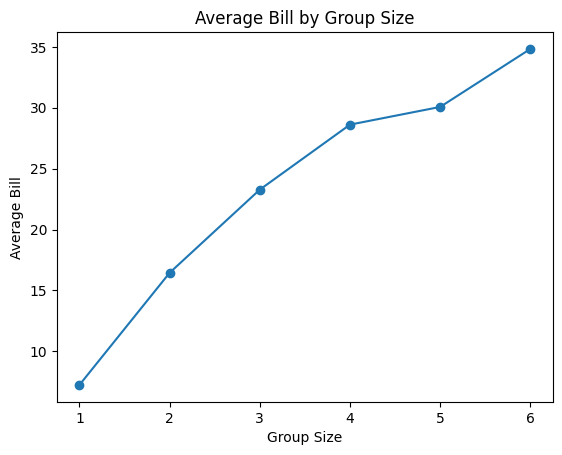

In [11]:
group_size.plot(kind="line", marker="o")

plt.title("Average Bill by Group Size")
plt.xlabel("Group Size")
plt.ylabel("Average Bill")

plt.show()

Insights

• Dinner customers spend more on average than lunch customers.
• Larger groups generally have higher total bills.
• Spending increases as group size increases, suggesting social dining leads to higher revenue.

In [21]:
sales = pd.read_csv(r"C:\Users\spenc\Downloads\train.csv")

sales.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [22]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [24]:
sales["Order Date"] = pd.to_datetime(sales["Order Date"], dayfirst=True)

In [25]:
sales["Month"] = sales["Order Date"].dt.to_period("M")

In [26]:
monthly_sales = sales.groupby("Month")["Sales"].sum()

monthly_sales

Month
2015-01     14205.7070
2015-02      4519.8920
2015-03     55205.7970
2015-04     27906.8550
2015-05     23644.3030
2015-06     34322.9356
2015-07     33781.5430
2015-08     27117.5365
2015-09     81623.5268
2015-10     31453.3930
2015-11     77907.6607
2015-12     68167.0585
2016-01     18066.9576
2016-02     11951.4110
2016-03     32339.3184
2016-04     34154.4685
2016-05     29959.5305
2016-06     23599.3740
2016-07     28608.2590
2016-08     36818.3422
2016-09     63133.6060
2016-10     31011.7375
2016-11     75249.3995
2016-12     74543.6012
2017-01     18542.4910
2017-02     22978.8150
2017-03     51165.0590
2017-04     38679.7670
2017-05     56656.9080
2017-06     39724.4860
2017-07     38320.7830
2017-08     30542.2003
2017-09     69193.3909
2017-10     59583.0330
2017-11     79066.4958
2017-12     95739.1210
2018-01     43476.4740
2018-02     19920.9974
2018-03     58863.4128
2018-04     35541.9101
2018-05     43825.9822
2018-06     48190.7277
2018-07     44825.1040
2018-

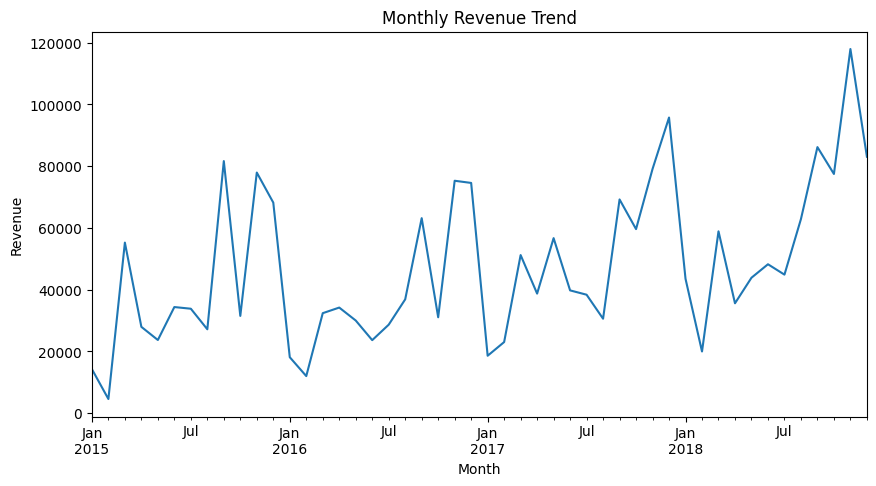

In [27]:
monthly_sales.plot(figsize=(10,5))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

In [28]:
region_sales = sales.groupby("Region")["Profit"].sum().sort_values(ascending=False)
region_sales

KeyError: 'Column not found: Profit'

In [29]:
sales.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Month'],
      dtype='str')

In [30]:
sales.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Month
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017-11
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017-11
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017-06
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016-10
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016-10


In [31]:
region_sales = sales.groupby("Region")["Sales"].sum().sort_values(ascending=False)

region_sales

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

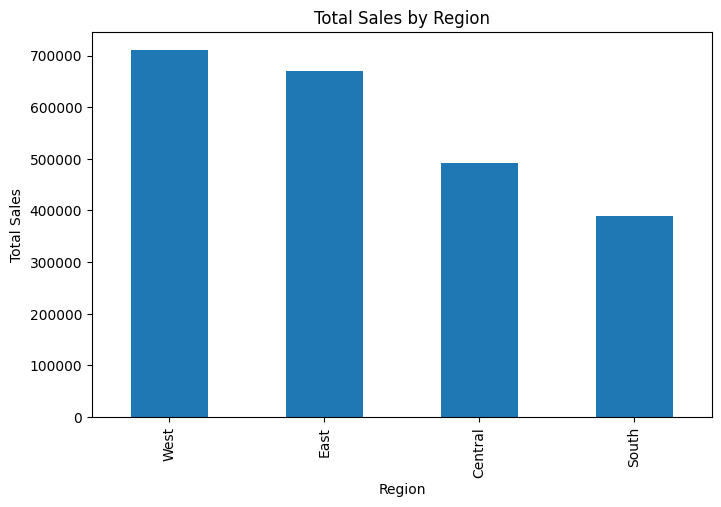

In [32]:
region_sales.plot(kind="bar", figsize=(8,5))

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

In [33]:
category_sales = sales.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

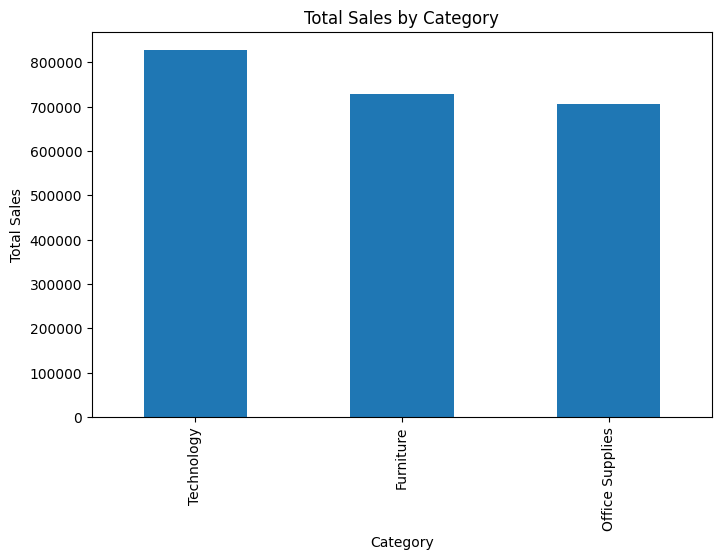

In [34]:
category_sales.plot(kind="bar", figsize=(8,5))

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

In [35]:
top_products = sales.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

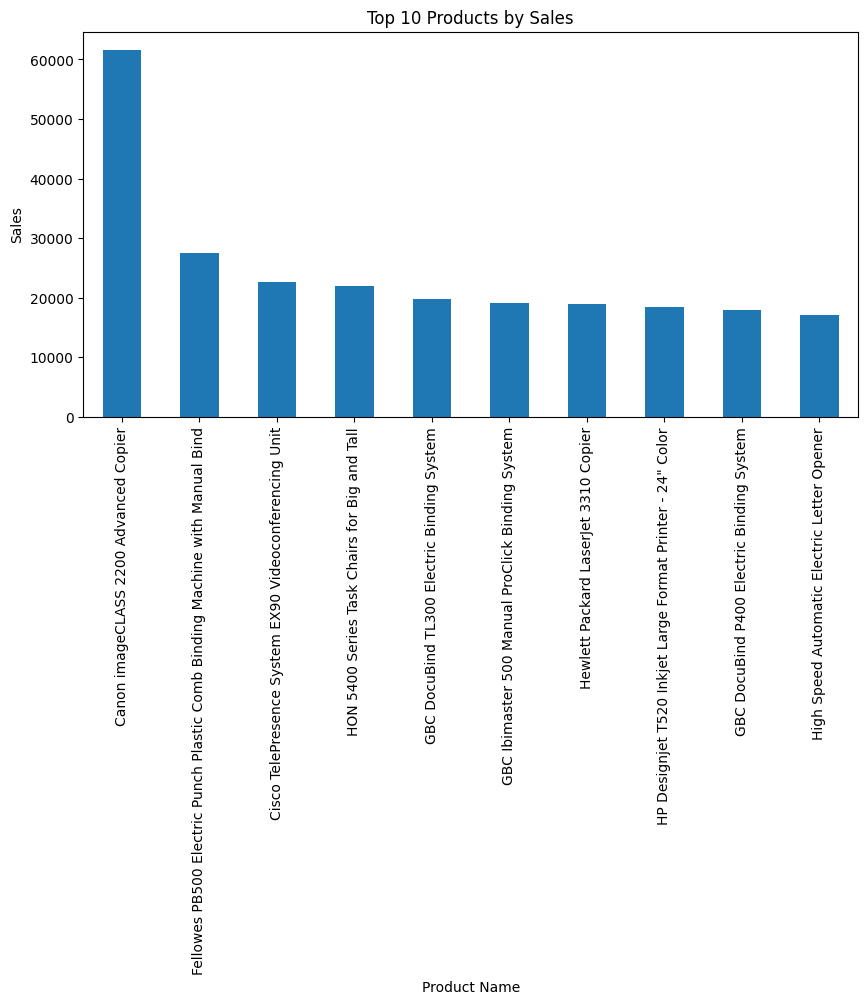

In [36]:
top_products.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Products by Sales")
plt.ylabel("Sales")

plt.show()

In [37]:
segment_sales = sales.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

segment_sales

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64

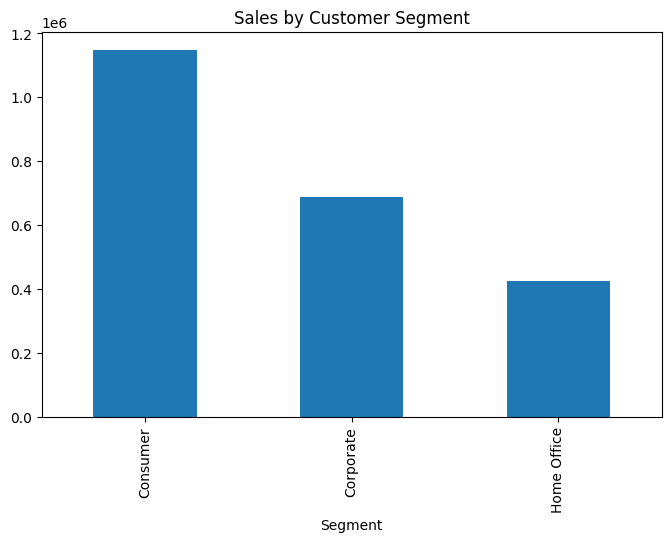

In [38]:
segment_sales.plot(kind="bar", figsize=(8,5))

plt.title("Sales by Customer Segment")

plt.show()

In [ ]:
Insights

• The West region generates the highest revenue overall.
• Technology products appear to drive significant sales compared to other categories.
• Consumer segment contributes the largest share of total sales.
• A small number of products generate a large portion of revenue.

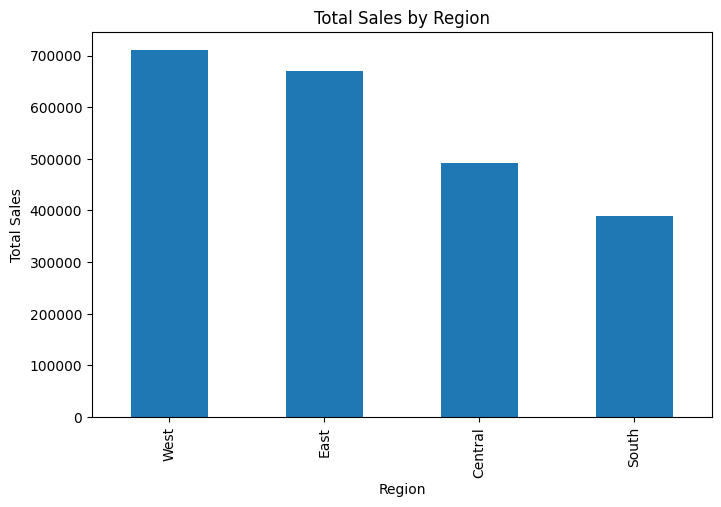

In [39]:
region_sales = sales.groupby("Region")["Sales"].sum().sort_values(ascending=False)

region_sales.plot(kind="bar", figsize=(8,5))

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.savefig("region_sales_chart.png")

plt.show()

In [40]:
import os
os.listdir()

['.cache',
 '.eclipse',
 '.ipynb_checkpoints',
 '.ipython',
 '.matplotlib',
 '.ms-ad',
 '.p2',
 'AppData',
 'Application Data',
 'archive.zip',
 'Contacts',
 'Cookies',
 'CrossDevice',
 'Documents',
 'Downloads',
 'eclipse',
 'eclipse-workspace',
 'Favorites',
 'Links',
 'Local Settings',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{68407e35-4390-11ef-b0c8-00155d012b0b}.TM.blf',
 'NTUSER.DAT{68407e35-4390-11ef-b0c8-00155d012b0b}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{68407e35-4390-11ef-b0c8-00155d012b0b}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OneDrive',
 'PrintHood',
 'Recent',
 'region_sales_chart.png',
 'sales_analysis.ipynb',
 'Saved Games',
 'Searches',
 'SendTo',
 'source',
 'Start Menu',
 'Templates',
 'Videos']

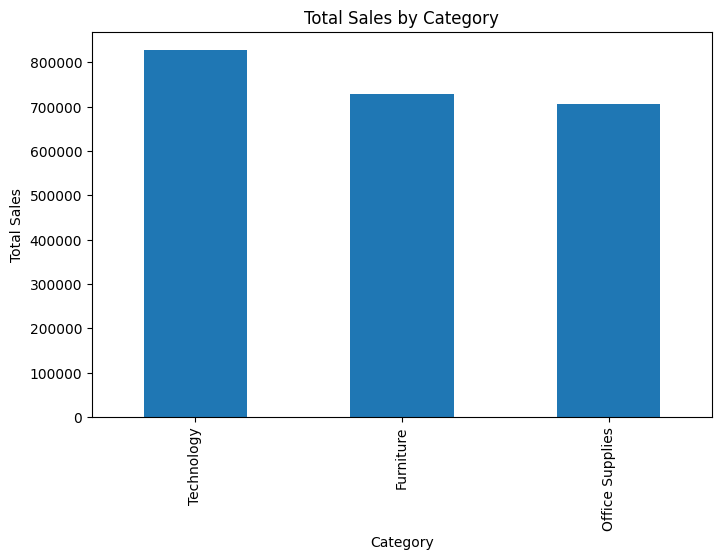

In [41]:
category_sales = sales.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales.plot(kind="bar", figsize=(8,5))

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.savefig("category_sales_chart.png")

plt.show()

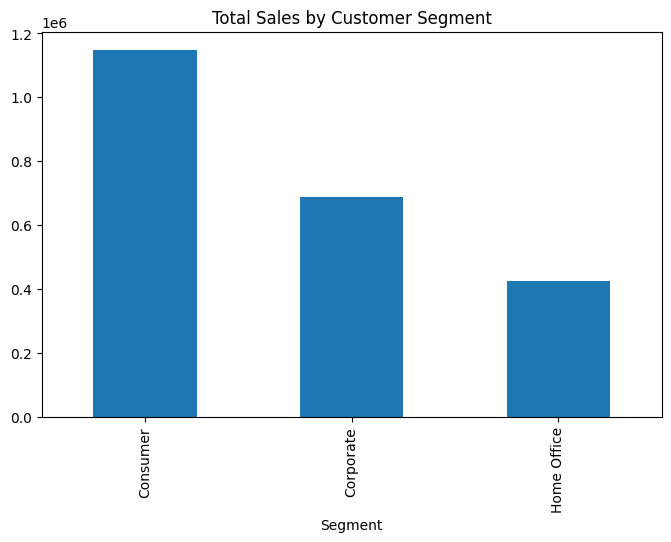

In [42]:
segment_sales = sales.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

segment_sales.plot(kind="bar", figsize=(8,5))

plt.title("Total Sales by Customer Segment")

plt.savefig("segment_sales_chart.png")

plt.show()

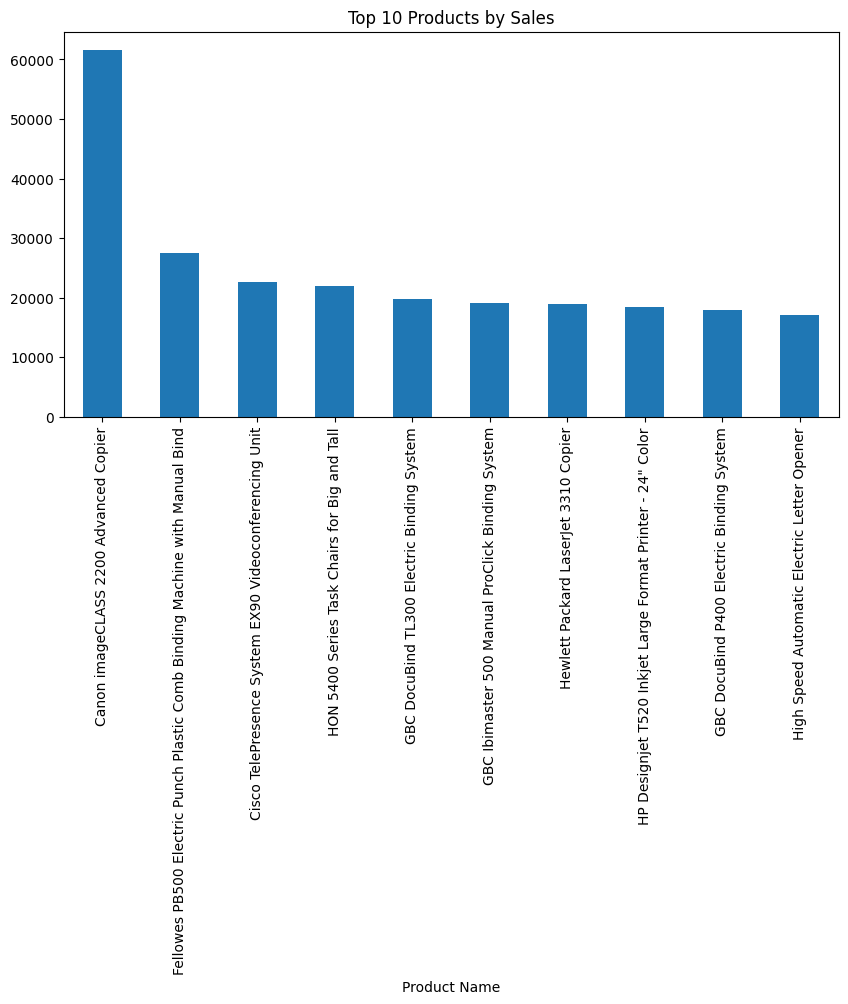

In [44]:
top_products = sales.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

top_products.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Products by Sales")

plt.savefig("top_products_chart.png")

plt.show()